In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('C:\\Users\\HP\\OneDrive\\Desktop\\kpmg\\SEM 3\\machine learning\\kmean cluster\\marketing-kmeans-customer-dataset.csv')

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9030 entries, 0 to 9029
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             9030 non-null   int64  
 1   Age                     8930 non-null   float64
 2   Annual_Income           8909 non-null   float64
 3   Purchase_Frequency      9030 non-null   float64
 4   Average_Order_Value     9030 non-null   int64  
 5   Recency_Days            9030 non-null   int64  
 6   Website_Visits_Monthly  9030 non-null   int64  
 7   Discount_Usage_Pct      9030 non-null   float64
 8   Annual_Spend            9030 non-null   float64
 9   City                    9030 non-null   object 
 10  Preferred_Channel       9030 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 776.1+ KB
None


In [5]:
df.head(5)

,Customer_ID,Age,Annual_Income,Purchase_Frequency,Average_Order_Value,Recency_Days,Website_Visits_Monthly,Discount_Usage_Pct,Annual_Spend,City,Preferred_Channel
0,102374,33.0,51400.0,3.9,500,168,6,80.9,1932.30,Bengaluru,Website
1,107803,47.0,169200.0,14.2,3640,22,17,24.9,51613.73,Chennai,Mobile App
2,105124,29.0,84100.0,7.3,1320,64,16,56.1,9675.98,Delhi,Marketplace
3,106109,28.0,87600.0,9.7,1930,42,13,28.3,18696.83,Bengaluru,Mobile App
4,106012,38.0,57800.0,9.1,1770,67,9,57.9,16079.51,Hyderabad,Website


In [6]:
df.tail(10)

,Customer_ID,Age,Annual_Income,Purchase_Frequency,Average_Order_Value,Recency_Days,Website_Visits_Monthly,Discount_Usage_Pct,Annual_Spend,City,Preferred_Channel
9020,108323,34.0,NaN,18.7,5040,18,33,36.5,94129.65,Pune,Website
9021,105579,25.0,88000.0,10.5,1640,64,14,43.8,17274.39,Mumbai,Mobile App
9022,104427,34.0,87900.0,11.1,1630,52,14,48.3,18036.89,Pune,Website
9023,100467,34.0,48500.0,3.4,930,171,4,55.7,3183.89,Mumbai,Website
9024,106266,37.0,95300.0,8.4,1940,53,12,48.9,16239.51,Hyderabad,Mobile App
9025,105735,34.0,79300.0,6.9,1790,42,14,58.8,12443.82,Bengaluru,Website
9026,105192,26.0,88300.0,9.4,1790,53,9,43.1,16833.90,Bengaluru,Website
9027,105391,26.0,93700.0,7.4,1530,42,11,55.6,11340.72,Delhi,Marketplace
9028,100861,36.0,46600.0,4.0,900,177,5,43.2,3615.18,Mumbai,Mobile App
9029,107271,40.0,158000.0,18.3,3670,14,26,23.0,67090.96,Bengaluru,Mobile App


In [7]:
print('Numbers of rows and columns:')
print(df.shape)

print('\nColumns names:')
print(df.columns)

print('\Data types:')
print(df.dtypes)

Numbers of rows and columns:
(9030, 11)

Columns names:
Index(['Customer_ID', 'Age', 'Annual_Income', 'Purchase_Frequency',
       'Average_Order_Value', 'Recency_Days', 'Website_Visits_Monthly',
       'Discount_Usage_Pct', 'Annual_Spend', 'City', 'Preferred_Channel'],
      dtype='object')
\Data types:
Customer_ID                 int64
Age                       float64
Annual_Income             float64
Purchase_Frequency        float64
Average_Order_Value         int64
Recency_Days                int64
Website_Visits_Monthly      int64
Discount_Usage_Pct        float64
Annual_Spend              float64
City                       object
Preferred_Channel          object
dtype: object


In [8]:
df.isnull().sum()

Customer_ID                 0
Age                       100
Annual_Income             121
Purchase_Frequency          0
Average_Order_Value         0
Recency_Days                0
Website_Visits_Monthly      0
Discount_Usage_Pct          0
Annual_Spend                0
City                        0
Preferred_Channel           0
dtype: int64

In [9]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [10]:
df['Annual_Income']=df['Annual_Income'].fillna(df['Annual_Income'].median())

In [11]:
df.isnull().sum()

Customer_ID               0
Age                       0
Annual_Income             0
Purchase_Frequency        0
Average_Order_Value       0
Recency_Days              0
Website_Visits_Monthly    0
Discount_Usage_Pct        0
Annual_Spend              0
City                      0
Preferred_Channel         0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(30)

In [13]:
df=df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(9000, 11)

In [16]:
df.describe()

,Customer_ID,Age,Annual_Income,Purchase_Frequency,Average_Order_Value,Recency_Days,Website_Visits_Monthly,Discount_Usage_Pct,Annual_Spend
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,104500.500000,37.283778,89998.322222,9.378656,2135.345556,64.388444,14.017000,46.549878,27068.124434
std,2598.220545,6.490141,39991.699584,5.598700,1410.697250,45.355427,7.980881,21.165297,29647.115378
min,100001.000000,21.000000,23600.000000,1.100000,370.000000,3.000000,2.000000,2.000000,979.250000
25%,102250.750000,33.000000,55400.000000,3.900000,890.000000,23.000000,7.000000,29.200000,3276.912500
50%,104500.500000,37.000000,82500.000000,8.700000,1740.000000,52.000000,13.000000,46.500000,15105.725000
75%,106750.250000,42.000000,116000.000000,13.200000,3340.000000,99.000000,20.000000,65.200000,50156.335000
max,109000.000000,63.000000,235900.000000,28.500000,6660.000000,221.000000,41.000000,95.000000,148195.000000


# Basic EDA

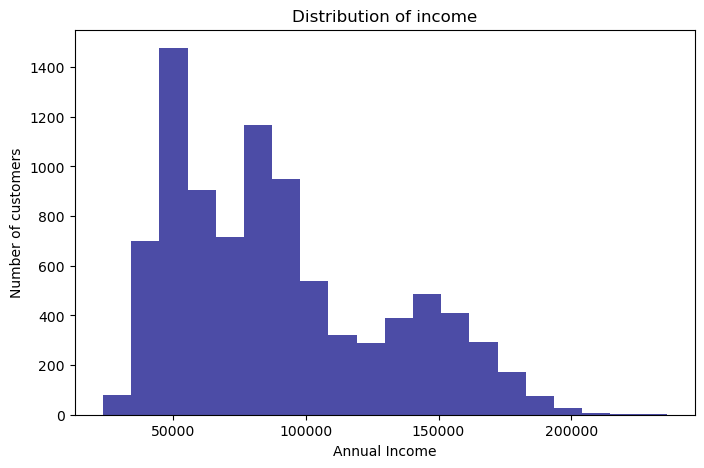

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df['Annual_Income'], bins=20, color='navy', alpha=0.7) 
plt.title('Distribution of income')
plt.xlabel('Annual Income')
plt.ylabel("Number of customers")
plt.show()

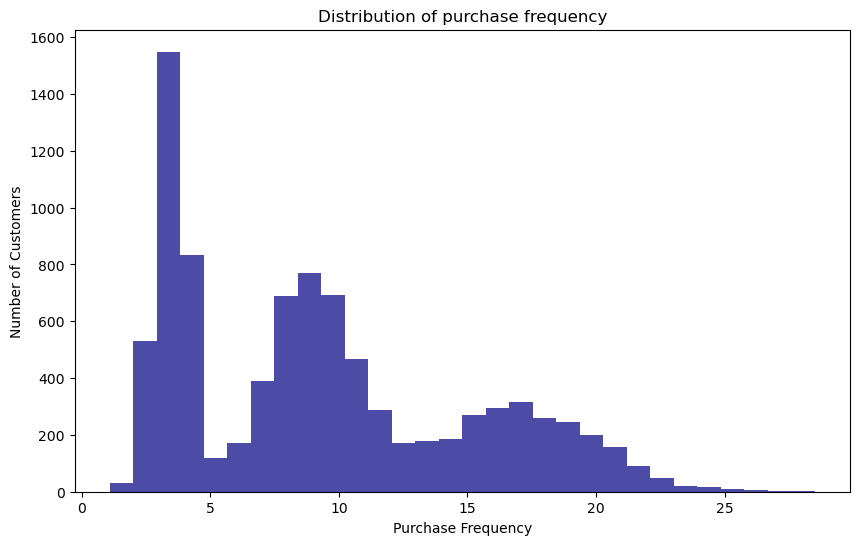

In [18]:
plt.figure(figsize=(10,6))
plt.hist(df['Purchase_Frequency'], bins=30, color='navy', alpha=0.7)
plt.title('Distribution of purchase frequency')
plt.xlabel('Purchase Frequency')
plt.ylabel("Number of Customers")
plt.show()

#### Annual Income vs Annual Spend 

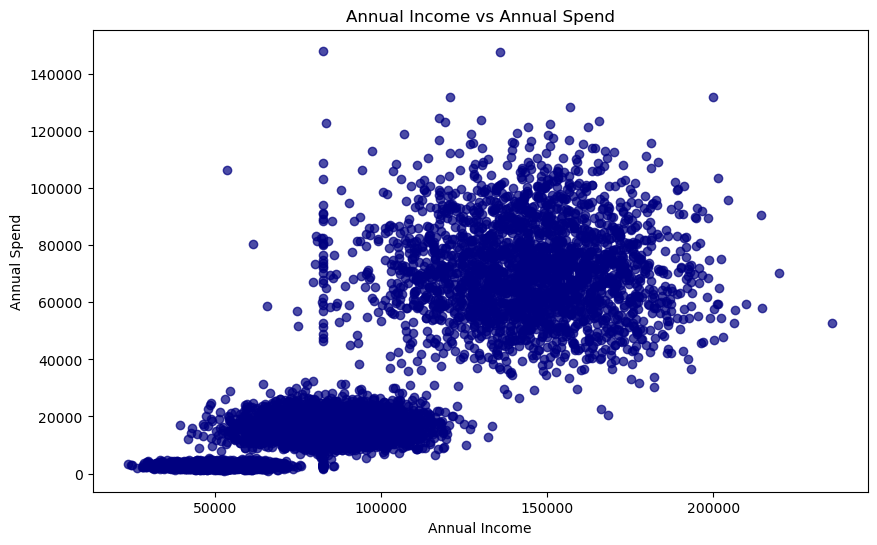

In [19]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Annual_Income"],
    df["Annual_Spend"],
    alpha=0.7,
    color='navy'
)
plt.xlabel("Annual Income")
plt.ylabel('Annual Spend')
plt.title('Annual Income vs Annual Spend')
plt.show()

In [20]:
# select features for clustering
# for clustering, use only behaioural and value-elated numerical variables. 
# inter cluster , intra cluster

features= [
    'Annual_Income',
    'Purchase_Frequency',
    'Average_Order_Value',
    'Recency_Days',
    'Website_Visits_Monthly',
    'Discount_Usage_Pct' 


]
X= df[features]

In [21]:
X.head(10)

,Annual_Income,Purchase_Frequency,Average_Order_Value,Recency_Days,Website_Visits_Monthly,Discount_Usage_Pct
0,51400.0,3.9,500,168,6,80.9
1,169200.0,14.2,3640,22,17,24.9
2,84100.0,7.3,1320,64,16,56.1
3,87600.0,9.7,1930,42,13,28.3
4,57800.0,9.1,1770,67,9,57.9
5,71000.0,9.6,1630,37,10,48.0
6,57000.0,3.9,730,154,6,77.1
7,106600.0,8.4,1850,51,12,45.8
8,158300.0,20.4,4470,25,33,31.5
9,85600.0,6.9,1830,54,12,48.8


In [22]:
# how to decide the number of clusters in kmeans


In [23]:
inertia=[]

for k in range(1,9):
    kmeans=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    

# plot elbow curve

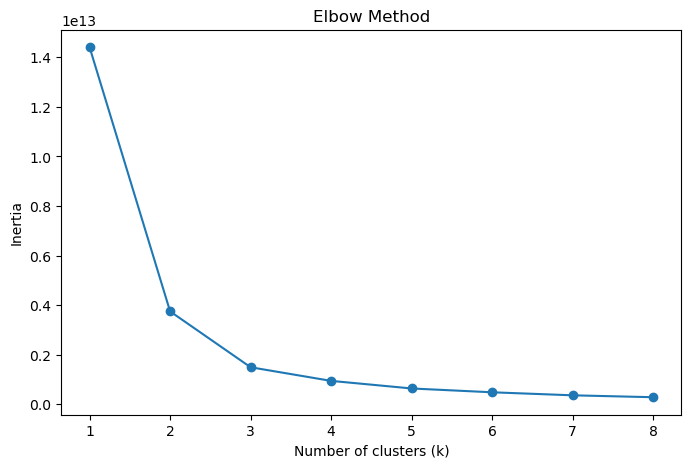

In [24]:
plt.figure(figsize=(8,5))


plt.plot(
    range(1,9),
    inertia,
    marker="o"
)


plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")


plt.show()

# apply k means clustering


In [25]:
kmeans=KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X)


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [26]:
# add cluster labels to the original dataframe

df['Cluster']=kmeans.labels_

In [27]:
# check first few row 
df.head(10)

,Customer_ID,Age,Annual_Income,Purchase_Frequency,Average_Order_Value,Recency_Days,Website_Visits_Monthly,Discount_Usage_Pct,Annual_Spend,City,Preferred_Channel,Cluster
0,102374,33.0,51400.0,3.9,500,168,6,80.9,1932.30,Bengaluru,Website,2
1,107803,47.0,169200.0,14.2,3640,22,17,24.9,51613.73,Chennai,Mobile App,1
2,105124,29.0,84100.0,7.3,1320,64,16,56.1,9675.98,Delhi,Marketplace,0
3,106109,28.0,87600.0,9.7,1930,42,13,28.3,18696.83,Bengaluru,Mobile App,0
4,106012,38.0,57800.0,9.1,1770,67,9,57.9,16079.51,Hyderabad,Website,2
5,103828,28.0,71000.0,9.6,1630,37,10,48.0,15630.74,Chennai,Website,2
6,102408,38.0,57000.0,3.9,730,154,6,77.1,2881.05,Pune,Marketplace,2
7,105833,28.0,106600.0,8.4,1850,51,12,45.8,15553.13,Chennai,Website,0
8,107435,37.0,158300.0,20.4,4470,25,33,31.5,91230.16,Mumbai,Mobile App,1
9,105652,38.0,85600.0,6.9,1830,54,12,48.8,12542.24,Mumbai,Website,0


In [28]:
df['Cluster'].value_counts().sort_index()

Cluster
0    3413
1    2104
2    3483
Name: count, dtype: int64

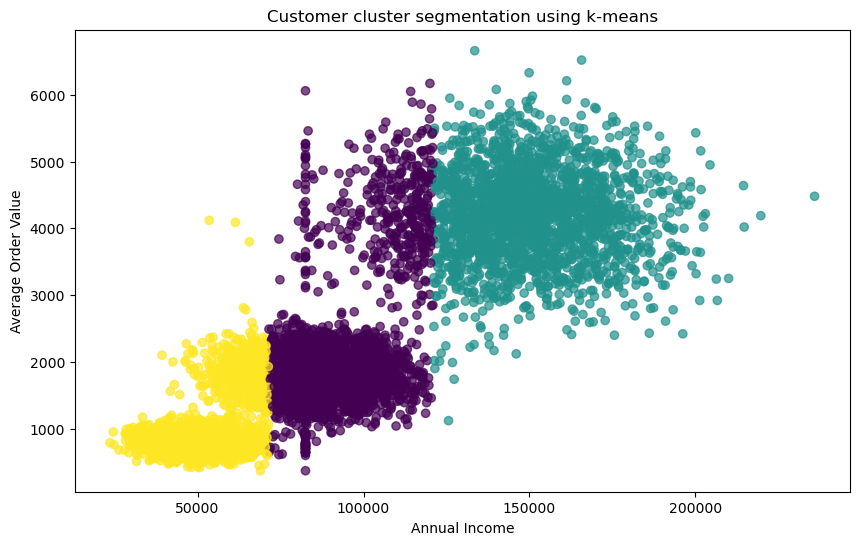

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Annual_Income"],
    df["Average_Order_Value"],
    c=df['Cluster'],
    cmap='viridis',
    alpha=0.7
)
plt.xlabel("Annual Income")
plt.ylabel('Average Order Value')
plt.title('Customer cluster segmentation using k-means')
plt.show()

In [32]:
# create cluster profile by calculating the mean of each feature for each cluster

cluster_profile= df.groupby('Cluster')[features].mean()
cluster_profile.round(2)

,Annual_Income,Purchase_Frequency,Average_Order_Value,Recency_Days,Website_Visits_Monthly,Discount_Usage_Pct
Cluster,,,,,,
0,90733.52,9.86,2064.99,47.54,14.35,42.43
1,151388.21,16.91,4196.37,18.12,24.97,20.23
2,52193.68,4.36,959.27,108.85,7.07,66.49


In [39]:
# Assign segments name 

income_order=(

    cluster_profile["Annual_Income"].sort_values().index
    


)
cluster_names= {
    income_order[0]: "Budget / Ocassional",
    income_order[1]: "Regular / Growing",
    income_order[2]: "Premium / High Value"

}
cluster_names 

{np.int32(2): 'Budget / Ocassional',
 np.int32(0): 'Regular / Growing',
 np.int32(1): 'Premium / High Value'}

In [40]:
# create customer segment column in the original dataframe

# create a customer segment column in the original dataframe

df['Customer_Segment']=df['Cluster'].map(cluster_names)

# check 

df[
    [
        "Customer_ID",
        "Cluster",
        "Customer_Segment"

    ]
].head(10)

,Customer_ID,Cluster,Customer_Segment
0,102374,2,Budget / Ocassional
1,107803,1,Premium / High Value
2,105124,0,Regular / Growing
3,106109,0,Regular / Growing
4,106012,2,Budget / Ocassional
5,103828,2,Budget / Ocassional
6,102408,2,Budget / Ocassional
7,105833,0,Regular / Growing
8,107435,1,Premium / High Value
9,105652,0,Regular / Growing
